# ML Pipeline
## Phase 1: Setup and Data Preperation
Load data, select right features for the model, ensure datas are in usable format. Handle Categorical Data. Scale the data

## Phase 2: Unsupervised Learning - Discovering Grip Strategies
Use the kinematic data to find natural groupings, which we will interpret as different "grip strategies". Do PCA, K Means Clustering Algorithm. Each Cluster will represent a grip strategy. Then assign cluster labels to the original DataFrame. Now every trial is assigned a grip strategy.
 
## Phase 3: Interpretation and Visualisation
Visualise the clusters. Use Cross tabulation to see how the discovered grip strategy relate to the experimental conditions (distance, surface). Eg. Strategy 0 is dominantly use for far distance and Strategy 1 is use for near distance.


## Phase 4: Supervised Learning
To build a machine learning model that can predict the experimental condition (like distance: near, middle, far) based solely on kinematic data (how the hand moved).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score


In [2]:
df = pd.read_csv("C:/CourseWork/Dissertation Classifying grip strategies using machine learning/data/02_processed/prehension_master_dataset.csv")
df.head(3)

,subjName,trialN,visCond,surface,distance,DOB,Gender,Dominant.Eye,clear.logMAR,mono.logMAR,...,timeToXmax_thumb,timeToXmax_wrist,timeToYmax_index,timeToYmax_knuck,timeToYmax_thumb,timeToYmax_wrist,timeToZmax_index,timeToZmax_knuck,timeToZmax_thumb,timeToZmax_wrist
0,1,1,clear,black,near,13/05/2003,Male,Right,-0.02,-0.04,...,3.308333,3.316667,2.691667,3.125,2.675000,2.758333,2.950000,2.966667,3.241667,2.983333
1,1,2,clear,black,far,13/05/2003,Male,Right,-0.02,-0.04,...,3.775000,4.050000,2.991667,3.500,2.941667,3.500000,3.608333,3.675000,3.625000,3.666667
2,1,3,clear,wood,middle,13/05/2003,Male,Right,-0.02,-0.04,...,3.666667,3.691667,2.908333,3.475,2.891667,3.483333,3.300000,3.325000,3.291667,3.325000


In [3]:
# 2. Feature Selection
# Define columns by their roles based on the new structure
identifier_cols = ['subjName', 'trialN', 'DOB', 'Gender', 'Dominant.Eye']
condition_cols = ['visCond', 'surface', 'distance']
# All other numeric columns are potential kinematic/vision features
kinematic_features = df.select_dtypes(include=np.number).columns.tolist()
# Remove identifier columns from the feature list
kinematic_features = [col for col in kinematic_features if col not in ['subjName', 'trialN']]

print(f"\nIdentified {len(kinematic_features)} kinematic and vision features for modeling.")


Identified 173 kinematic and vision features for modeling.


In [4]:
# 3. Handle Categorical Data (for supervised target) & Prepare Data
X = df[kinematic_features].copy()
y_supervised = df['distance']
groups = df['subjName']

# Check for and handle any potential missing values
if X.isnull().sum().sum() > 0:
    print("\nWarning: Missing values detected. Filling with the column mean.")
    X = X.fillna(X.mean())

In [5]:
# 4. Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nFeatures have been scaled using StandardScaler.")


Features have been scaled using StandardScaler.


#  Phase 2: Unsupervised Learning Discovering Grip Strategies

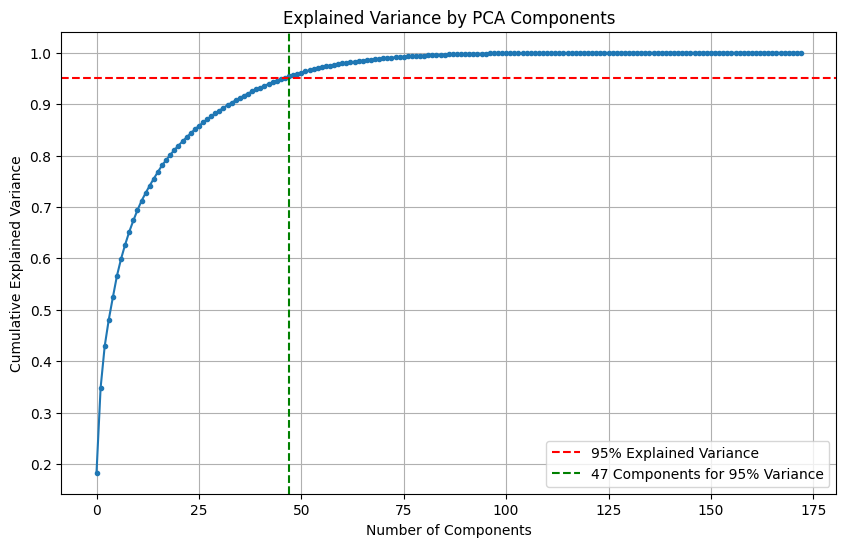


Number of components to explain 95% of variance: 47
Data transformed using PCA into 47 components.


In [7]:
# 1. Dimensionality Reduction (PCA)
# Determine the number of components to explain 95% of the variance
pca_test = PCA()
pca_test.fit(X_scaled)
n_components_95 = np.where(np.cumsum(pca_test.explained_variance_ratio_) >= 0.95)[0][0] + 1

# Plot the explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_test.explained_variance_ratio_), marker='.', linestyle='-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
plt.axvline(x=n_components_95, color='g', linestyle='--', label=f'{n_components_95} Components for 95% Variance')
plt.legend()
plt.show()

print(f"\nNumber of components to explain 95% of variance: {n_components_95}")

# Apply PCA with the chosen number of components
pca = PCA(n_components=n_components_95)
X_pca = pca.fit_transform(X_scaled)
print(f"Data transformed using PCA into {X_pca.shape[1]} components.")


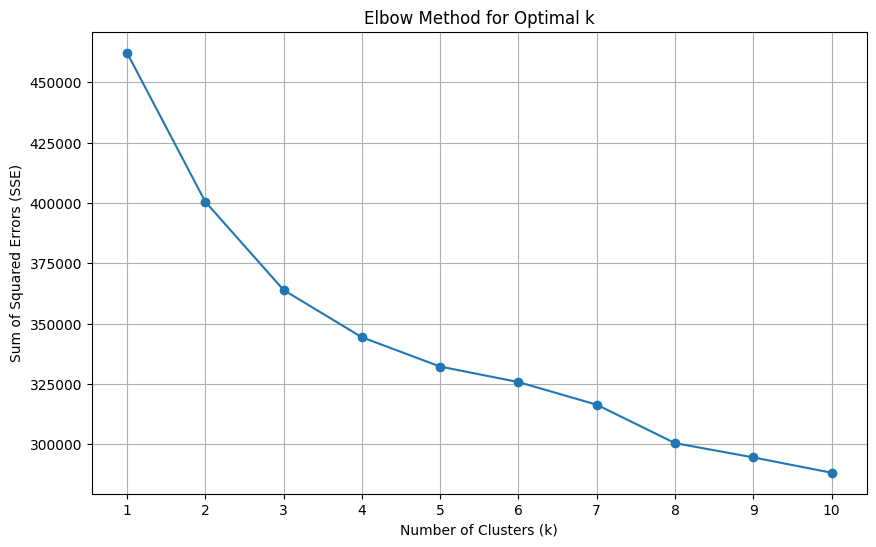

In [8]:
# 2. Clustering (K-Means)
# Use the Elbow Method to find the optimal number of clusters (k)
sse = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_pca)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(True)
plt.show()


In [9]:
optimal_k = 4
print(f"\nBased on the elbow plot, proceeding with k={optimal_k} clusters.")

# Apply K-Means with the optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_pca)

# 3. Assign Strategy Labels
df['grip_strategy'] = cluster_labels
print(f"Assigned trials to {optimal_k} discovered grip strategies.")



Based on the elbow plot, proceeding with k=4 clusters.
Assigned trials to 4 discovered grip strategies.


# Phase 3: Interpretation and Visualization


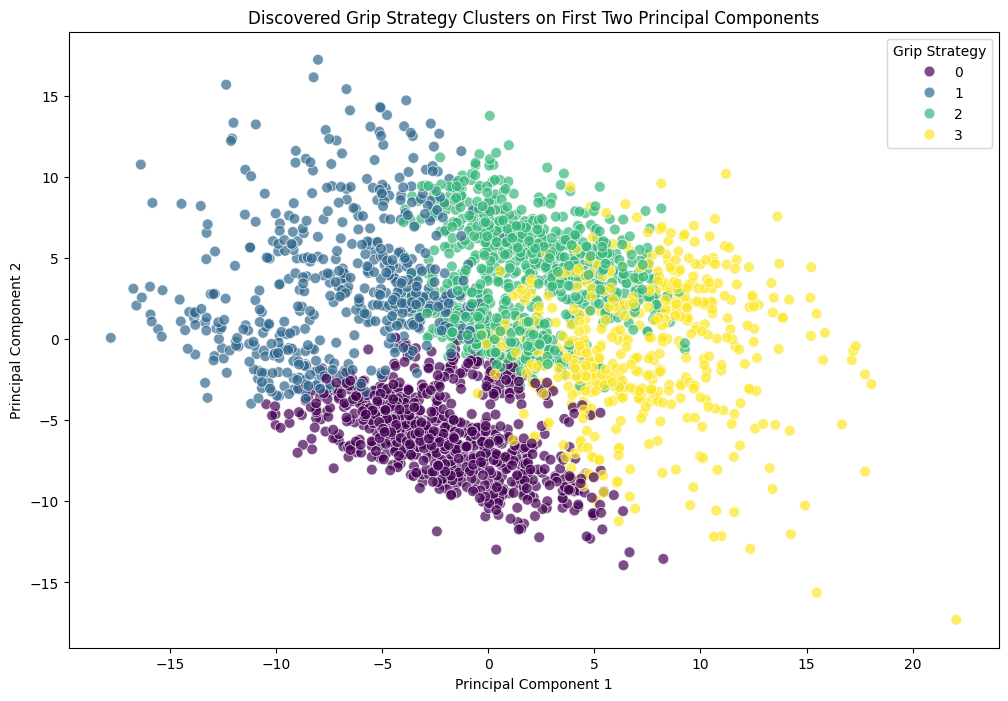

In [10]:
# 1. Visualize Clusters on PCA plot
pca_df = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['grip_strategy'] = cluster_labels

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='grip_strategy', data=pca_df, palette='viridis', alpha=0.7, s=60)
plt.title('Discovered Grip Strategy Clusters on First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Grip Strategy')
plt.show()


In [11]:
# 2. Analyze Cluster Characteristics via Crosstabs
print("\n--- Interpretation of Strategies ---")
print("\nRelationship between discovered strategies and 'distance' condition:")
print(pd.crosstab(df['grip_strategy'], df['distance']))

print("\nRelationship between discovered strategies and 'surface' condition:")
print(pd.crosstab(df['grip_strategy'], df['surface']))

# Analyze mean of key features for deeper insight
key_features_for_analysis = ['movTime', 'MVel', 'MAcc', 'MGA', 'pathLength', 'clear.logMAR']
cluster_analysis = df.groupby('grip_strategy')[key_features_for_analysis].mean()
print("\nMean of key kinematic and vision features for each grip strategy:")
print(cluster_analysis)


--- Interpretation of Strategies ---

Relationship between discovered strategies and 'distance' condition:
distance       far  middle  near
grip_strategy                   
0                2     104   732
1              102     259   169
2              591     327     0
3              243     251    46

Relationship between discovered strategies and 'surface' condition:
surface        black  wood
grip_strategy             
0                420   418
1                272   258
2                438   480
3                279   261

Mean of key kinematic and vision features for each grip strategy:
                movTime      MVel      MAcc       MGA  pathLength  \
grip_strategy                                                       
0              3.783134  0.855829  6.970752  0.107601    0.973297   
1              3.576491  1.128710  9.525450  0.110148    0.444084   
2              3.803558  1.326516  8.869234  0.109033    0.521065   
3              4.175417  1.284593  9.080105  0.1093

* Strategy 0:
    * Evidence: This strategy is overwhelmingly used for the near distance (732 trials) and rarely for far distance (only 2 trials).
    * Kinematics: It has the lowest MVel (Maximum Velocity) and lowest MAcc (Maximum Acceleration), but a very high pathLength.
    * Interpretation: A high path length for a short distance implies a more curved, less direct trajectory. Combined with low speed and acceleration, this suggests a slow, highly controlled movement. The subject isn't making a fast, ballistic reach.

* Strategy 1:
    * Evidence: This strategy is used across all distances but is most common for middle and near.
    * Kinematics: It has the shortest movTime (3.57s) and the lowest pathLength (0.444).
    * Interpretation: The movement is quick and follows the most direct path. It seems to be the "default" or most economical strategy used when the task is not at the extreme far distance, which requires a more powerful, specialized movement (like Strategy 2). The PCA plot shows this cluster (blue-green) is quite central, supporting its role as a general-purpose approach.

* Strategy 2:
    * Evidence: This strategy is predominantly used for the far distance (591 trials) and never for the near distance.
    * Kinematics: It has the highest MVel (1.326).
    * Interpretation: To cover a long distance, the brain executes a high-velocity, ballistic reach. The primary goal is to cover the distance quickly, so it "throws" the hand forward with maximum speed.

* Strategy 3:
    * Evidence: Used primarily for far and middle distances.
    * Kinematics: It has the longest movTime (4.17s) despite having a high MVel (1.28).
    * Interpretation: The hand accelerates quickly to cover the distance (high MVel) but then spends a very long time in the deceleration phase before grasping the object (long movTime). This might be a strategy for tasks that require both reaching a far object and being very precise at the end of the movement. It prioritizes a safe, carefully-controlled final approach over raw speed.


# Phase 4: Supervised Learning 

In [12]:
print("\n--- Phase 4: Supervised Learning (Predicting 'distance') ---")

# 1. Problem Formulation
# Features (X) are the scaled kinematic/vision features
# Target (y) is the 'distance' condition
le = LabelEncoder()
y_encoded = le.fit_transform(y_supervised)


--- Phase 4: Supervised Learning (Predicting 'distance') ---


In [13]:
pipeline = Pipeline([
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# Use GroupKFold for subject-aware splitting
group_kfold = GroupKFold(n_splits=5) 

print("\nPerforming 5-fold subject-aware cross-validation...")
# We pass the scaled data (X_scaled) to the pipeline
cv_scores = cross_val_score(pipeline, X_scaled, y_encoded, cv=group_kfold, groups=groups)

print(f"\nCross-validation accuracy scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")



Performing 5-fold subject-aware cross-validation...

Cross-validation accuracy scores: [0.99821747 1.         1.         1.         0.99644128]
Mean CV Accuracy: 0.9989 (+/- 0.0014)


Model Performance (Mean CV Accuracy: 99.89%):

An accuracy of nearly 100% means that the model can predict the target distance (near, middle, far) almost perfectly, based only on the kinematic and vision data.

In [14]:
# 3. Interpret the Supervised Model (Feature Importance)
# To get feature importances, we train the pipeline on the full dataset
pipeline.fit(X_scaled, y_encoded)
rf_model = pipeline.named_steps['classifier']
importances = rf_model.feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'feature': kinematic_features,
    'importance': importances
}).sort_values('importance', ascending=False)

C:\Users\bharg\AppData\Local\Temp\ipykernel_29276\1876994224.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='rocket')


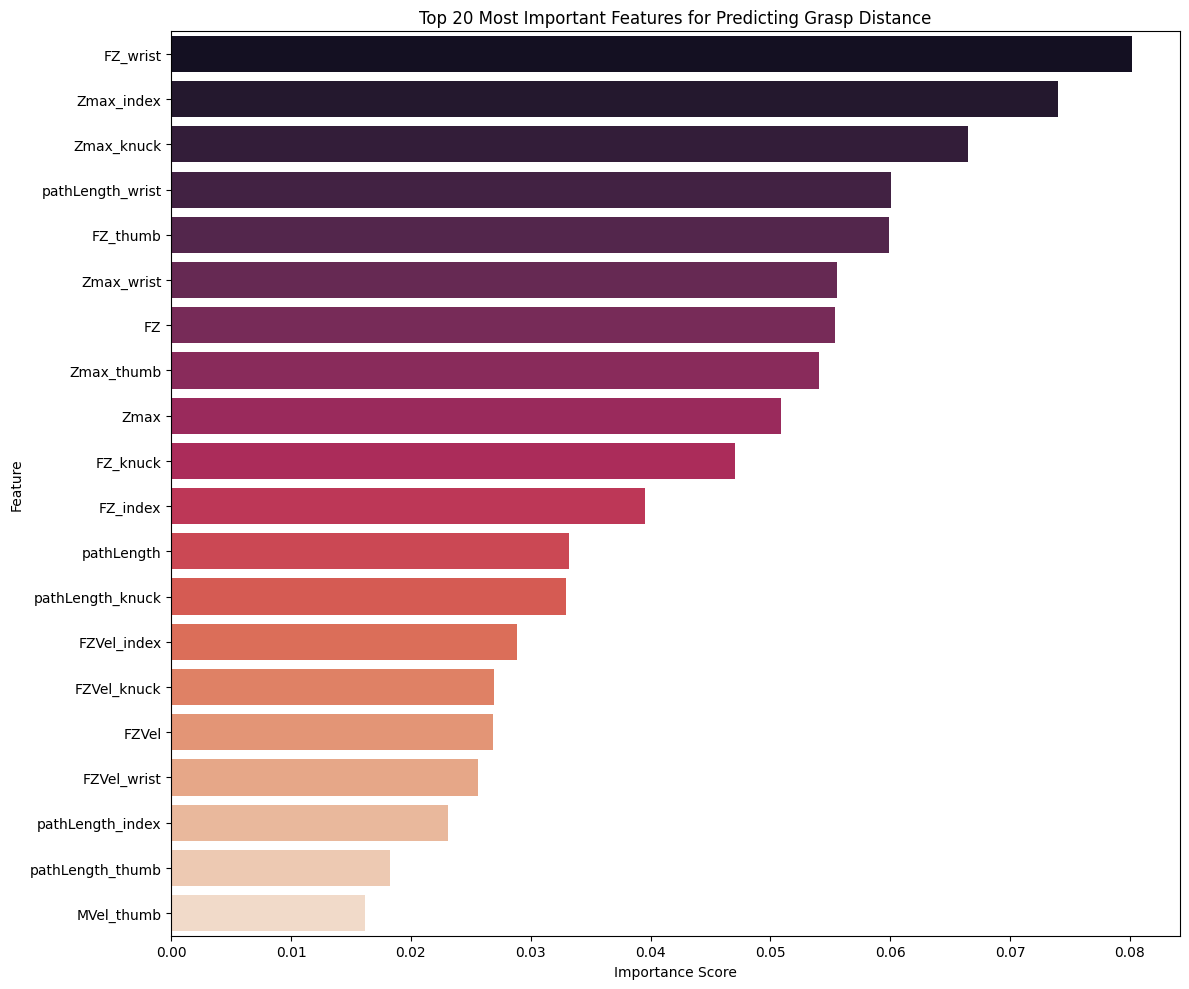


Top 10 most important features for predicting distance:
              feature  importance
80           FZ_wrist    0.080178
129        Zmax_index    0.074010
130        Zmax_knuck    0.066519
136  pathLength_wrist    0.060038
79           FZ_thumb    0.059872
132        Zmax_wrist    0.055573
11                 FZ    0.055382
131        Zmax_thumb    0.054088
26               Zmax    0.050894
78           FZ_knuck    0.047061


In [16]:
plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='rocket')
plt.title('Top 20 Most Important Features for Predicting Grasp Distance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 10 most important features for predicting distance:")
print(feature_importance_df.head(10))

Human grasping is not a single, uniform action but is composed of several classifiable strategies (e.g., "Ballistic Reach," "Corrective Grip").

The primary factor determining which strategy is chosen is the distance to the target object.

The most critical kinematic variables for planning a reach to a specific distance are the amplitude (Zmax) and force (FZ) of the movement in the forward direction.